In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [37]:
data=pd.read_csv("intraday.csv",parse_dates=["time"],index_col=["time"])

In [38]:
data

,price
time,
2018-01-01 22:00:00+00:00,1.201205
2018-01-02 04:00:00+00:00,1.207055
2018-01-02 10:00:00+00:00,1.204440
2018-01-02 16:00:00+00:00,1.205800
2018-01-02 22:00:00+00:00,1.204690
...,...
2019-12-29 22:00:00+00:00,1.119920
2019-12-30 04:00:00+00:00,1.119940
2019-12-30 10:00:00+00:00,1.120095


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2070 entries, 2018-01-01 22:00:00+00:00 to 2019-12-30 22:00:00+00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   2070 non-null   float64
dtypes: float64(1)
memory usage: 32.3 KB


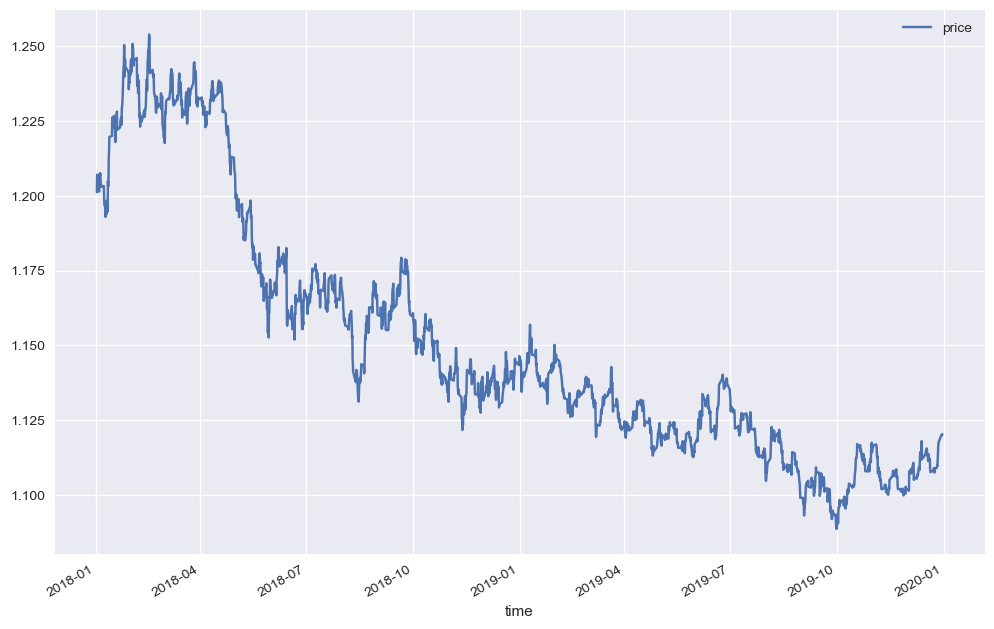

In [40]:
data.plot(figsize=(12,8))
plt.show()    

<Axes: xlabel='time'>

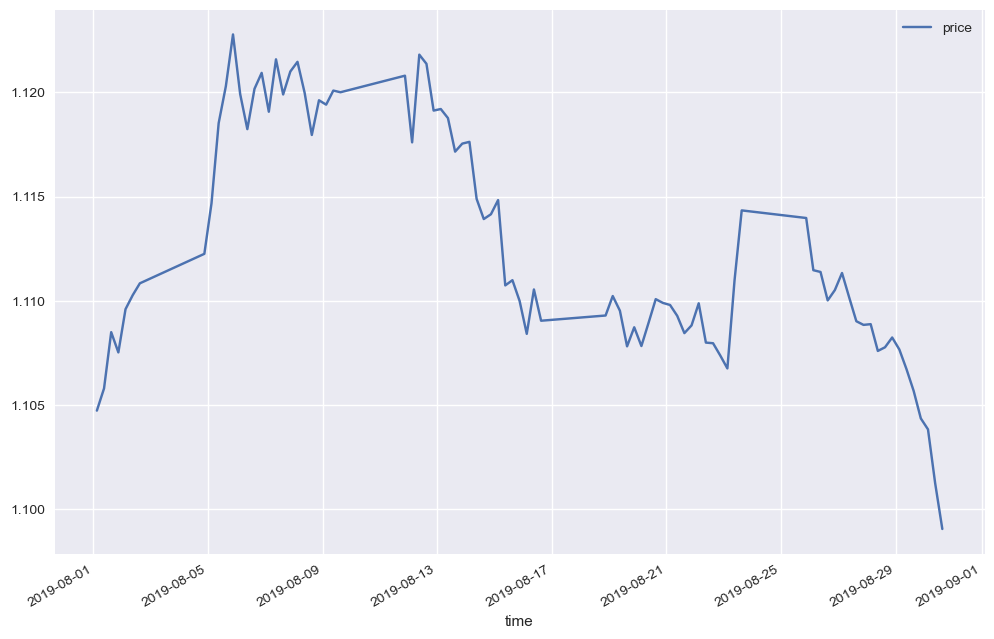

In [41]:
data.loc["2019-08"].plot(figsize=(12,8))

In [42]:
data["returns"] = np.log(data.price.div(data.price.shift(1)))

In [43]:
data

,price,returns
time,,
2018-01-01 22:00:00+00:00,1.201205,NaN
2018-01-02 04:00:00+00:00,1.207055,0.004858
2018-01-02 10:00:00+00:00,1.204440,-0.002169
2018-01-02 16:00:00+00:00,1.205800,0.001129
2018-01-02 22:00:00+00:00,1.204690,-0.000921
...,...,...
2019-12-29 22:00:00+00:00,1.119920,0.002092
2019-12-30 04:00:00+00:00,1.119940,0.000018
2019-12-30 10:00:00+00:00,1.120095,0.000138


Defining a Mean Reversion startegy for bollinger bands

In [44]:
SMA =30
dev =2

In [45]:
data["SMA"] = data["price"].rolling(SMA).mean()


<Axes: xlabel='time'>

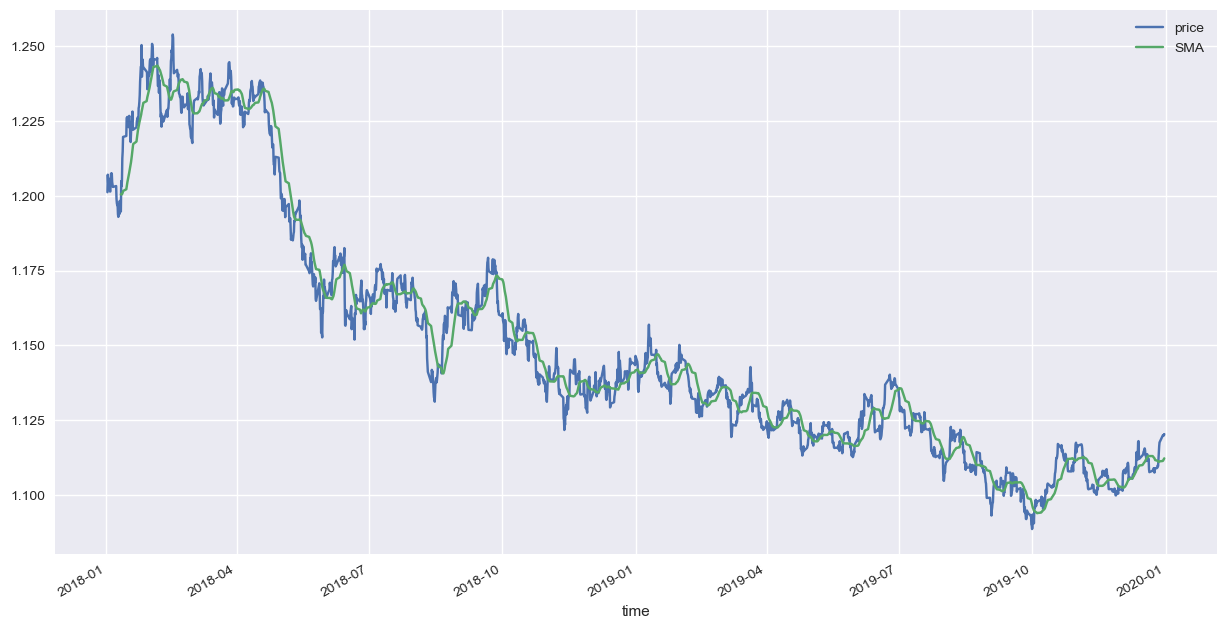

In [46]:
data[["price","SMA"]].plot(figsize=(15,8))

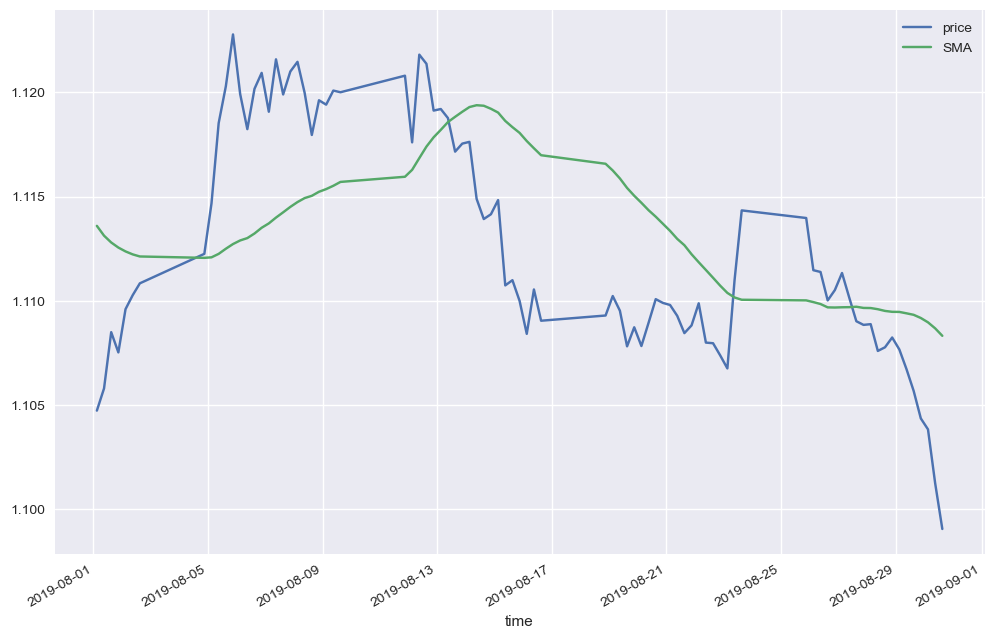

In [47]:
data.loc["2019-08",["price","SMA"]].plot(figsize=(12,8))
plt.show()

In [51]:
data["down"] = data["SMA"]-data["price"].rolling(SMA).std()*dev
data["up"] = data["SMA"]+data["price"].rolling(SMA).std()*dev


<Axes: xlabel='time'>

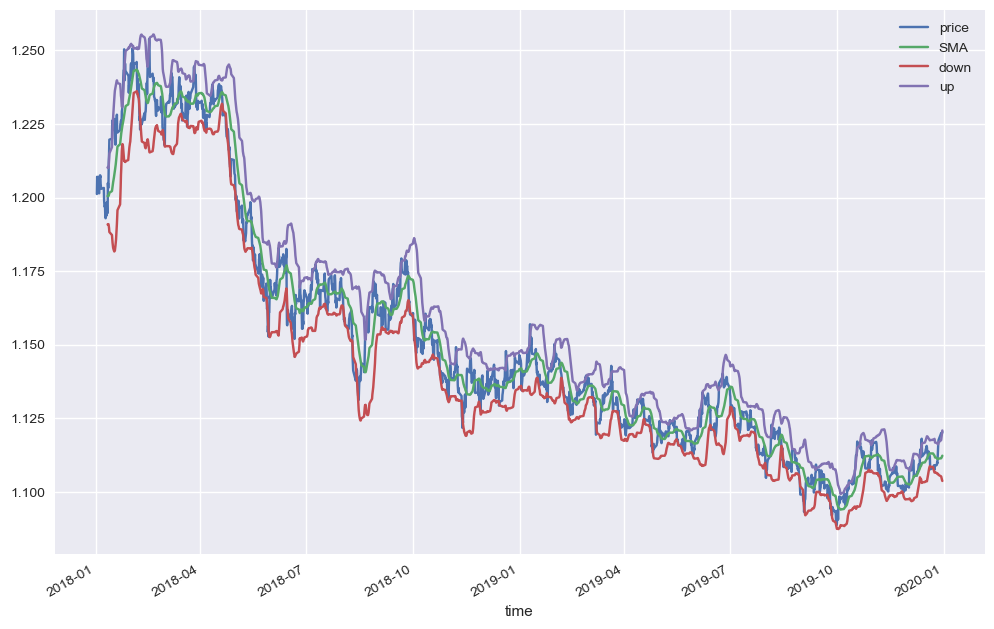

In [52]:
data.drop(columns = "returns").plot(figsize=(12,8))

<Axes: xlabel='time'>

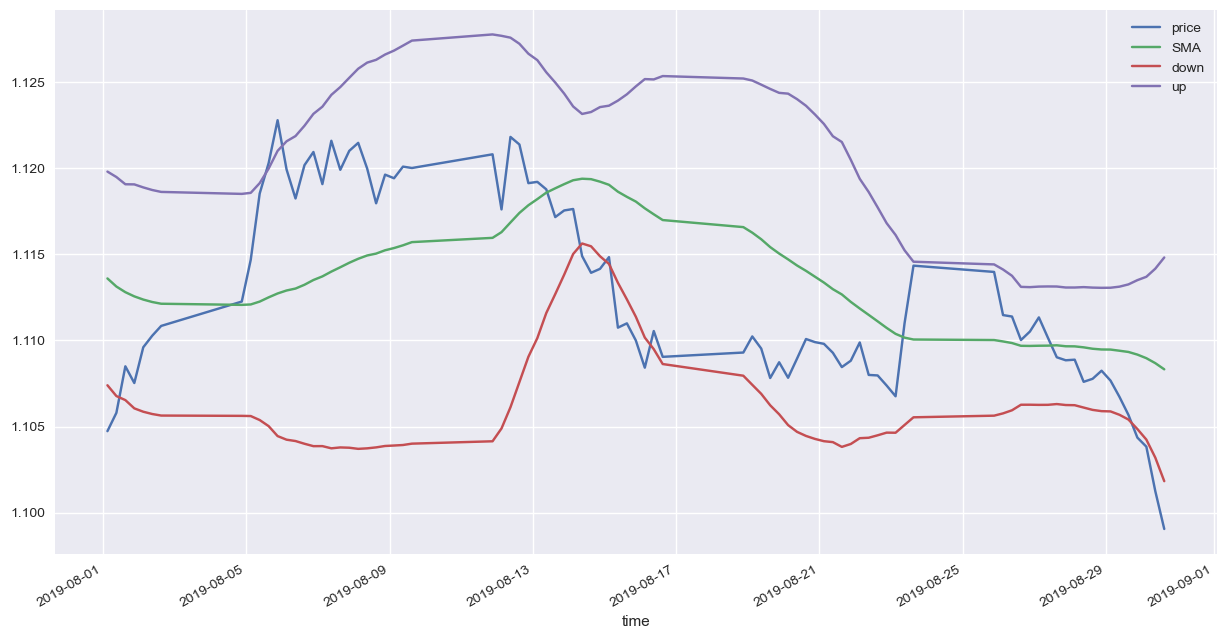

In [53]:
data.drop(columns="returns").loc["2019-08"].plot(figsize=(15,8))